In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/steven/thesis/mod")
from model_independent import model_independent

0 5
5 10
10 15
15 20
20 25
25 30
30 35
35 40
40 45
45 50
50 55
55 60
60 65
65 70
70 75


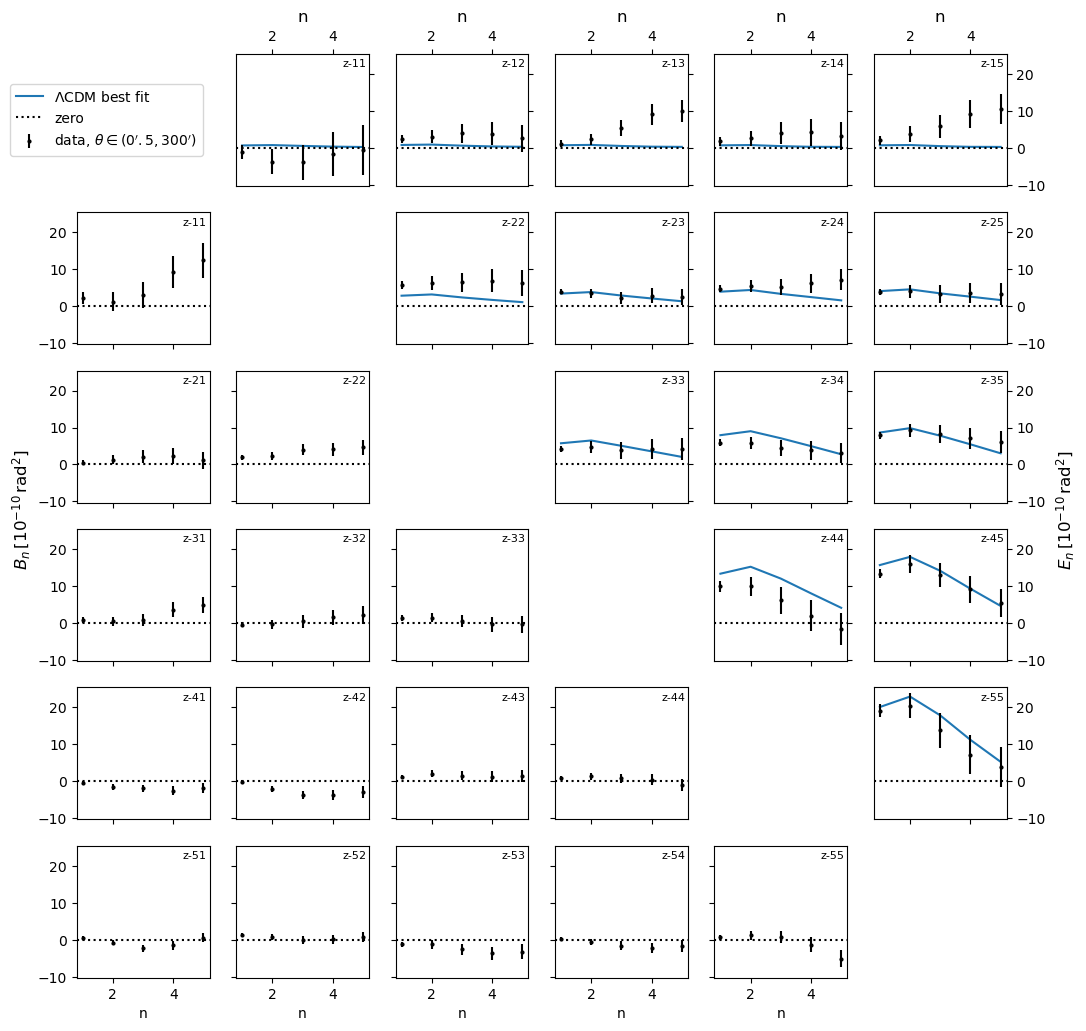

In [33]:
E_pattern = (
    "COSEBIs_05/En_COSEBIS_K1000_ALL_BLIND_C_V1.0.0A_ugriZYJHKs_photoz_"
    "SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid_theta_0.5_300_zbins_{i}_{j}.asc"
)
B_pattern = (
    "COSEBIs_05/Bn_COSEBIS_K1000_ALL_BLIND_C_V1.0.0A_ugriZYJHKs_photoz_"
    "SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid_theta_0.5_300_zbins_{i}_{j}.asc"
)
best_fit = np.loadtxt("data-theory_kids_non_lin.txt")[:,1] * 1e10
n_bins = 5
modes_per_pair = 5
modes = np.arange(1, modes_per_pair + 1)

covE_file = "cov_en_05.ascii"   # 75x75 covariance for E-modes
covE = np.loadtxt(covE_file)
errE = np.sqrt(np.diag(covE))
covB_file = "cov_bn_05.ascii"   # 75x75 covariance for B-modes
covB = np.loadtxt(covB_file)
errB = np.sqrt(np.diag(covB))
fig,axes = plt.subplots(n_bins+1,n_bins+1,figsize=(12,12),sharex=True,sharey=True)
countB = 0
countE = 0
for i in range(0,n_bins+1) :
    for j in range(0,n_bins+1) :
        ax = axes[i,j]
        if i == j :
            ax.axis("off")
            continue
        if i>j :
            data = B_pattern.format(i=j+1,j=i)
            cosebis = np.loadtxt(data) * 1e10
            err = errB[5*countB : 5*countB + 5] * 1e10
            ax.errorbar(modes,cosebis,yerr=err, fmt="o", color="k", label=r"data, $\theta \in (0'.5,300')$",markersize=2)
            ax.axhline(0, ls=":", color="k", label="zero")
            ax.text(0.80, 0.9, f"z-{i}{j+1}", transform=ax.transAxes, fontsize=8)
            if i==n_bins :
                ax.set_xlabel("n")
            if j == 0:
                ax.tick_params(labelleft=True)
            else:
                ax.tick_params(labelleft=False)
            countB+=1
        else :
            data = E_pattern.format(i=i+1,j=j)
            cosebis = np.loadtxt(data) * 1e10
            err = errE[5*countE : 5*countE + 5] * 1e10
            theory = best_fit[5*countE : 5*countE + 5]
            print(5*countE , 5*countE + 5)
            ax.plot(modes, theory, label=r"$\Lambda$CDM best fit")
            ax.errorbar(modes,cosebis,yerr=err, fmt="o", color="k", label=r"data, $\theta \in (0'.5,300')$",markersize=2)
            ax.axhline(0, ls=":", color="k", label="zero")
            ax.yaxis.set_ticks_position("right")
            ax.text(0.80, 0.9, f"z-{i+1}{j}", transform=ax.transAxes, fontsize=8)
            if i==0 :
                ax.set_title("n")
                ax.xaxis.set_ticks_position("top")
            if j == n_bins:
                ax.tick_params(labelright=True)
            else:
                ax.tick_params(labelright=False)
            countE+=1

# Collect handles/labels from all axes
handles, labels = [], []
for row in axes:
    for ax in row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Deduplicate while keeping order
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))

# Put legend into the empty top-left subplot (0,0)
axes[0,0].legend(by_label.values(), by_label.keys(),
                 loc="right")

fig.text(0.07, 0.5, r"$B_n \,[10^{-10}\,\mathrm{rad}^2]$", 
         va="center", rotation="vertical", fontsize=12)

fig.text(0.94, 0.5, r"$E_n \,[10^{-10}\,\mathrm{rad}^2]$", 
         va="center", rotation="vertical", fontsize=12)
        
plt.savefig("test.pdf")

0 5
5 10
10 15
15 20
20 25
[5.21764306 6.41604466 6.82199478 6.88740708 6.89225461]
25 30
30 35
35 40
40 45
[2.54813523 3.13339745 3.33165091 3.36359625 3.36596364]
[2.15062844 2.64459027 2.81191638 2.83887827 2.84087635]
45 50
50 55
55 60
[2.43112399 2.98951076 3.17866036 3.20913876 3.21139743]
[2.53600847 3.11848538 3.31579534 3.34758865 3.34994476]
[2.48886062 3.06050849 3.25415019 3.28535242 3.28766473]
60 65
65 70
[1.48534893 1.82650768 1.9420728  1.96069426 1.96207424]
[1.67907546 2.0647298  2.1953675  2.21641766 2.21797763]
[1.75151477 2.15380716 2.29008088 2.31203919 2.31366646]
[1.77290881 2.18011504 2.31805329 2.34027981 2.34192695]
70 75
[1.4171412  1.74263382 1.85289215 1.8706585  1.87197512]
[1.47828005 1.81781519 1.93283033 1.95136317 1.95273658]
[2.26553016 2.78588292 2.96214876 2.99055115 2.99265597]
[1.67108461 2.0549036  2.18491959 2.20586956 2.2074221 ]
[2.46522764 3.03144743 3.22325041 3.25415636 3.25644671]


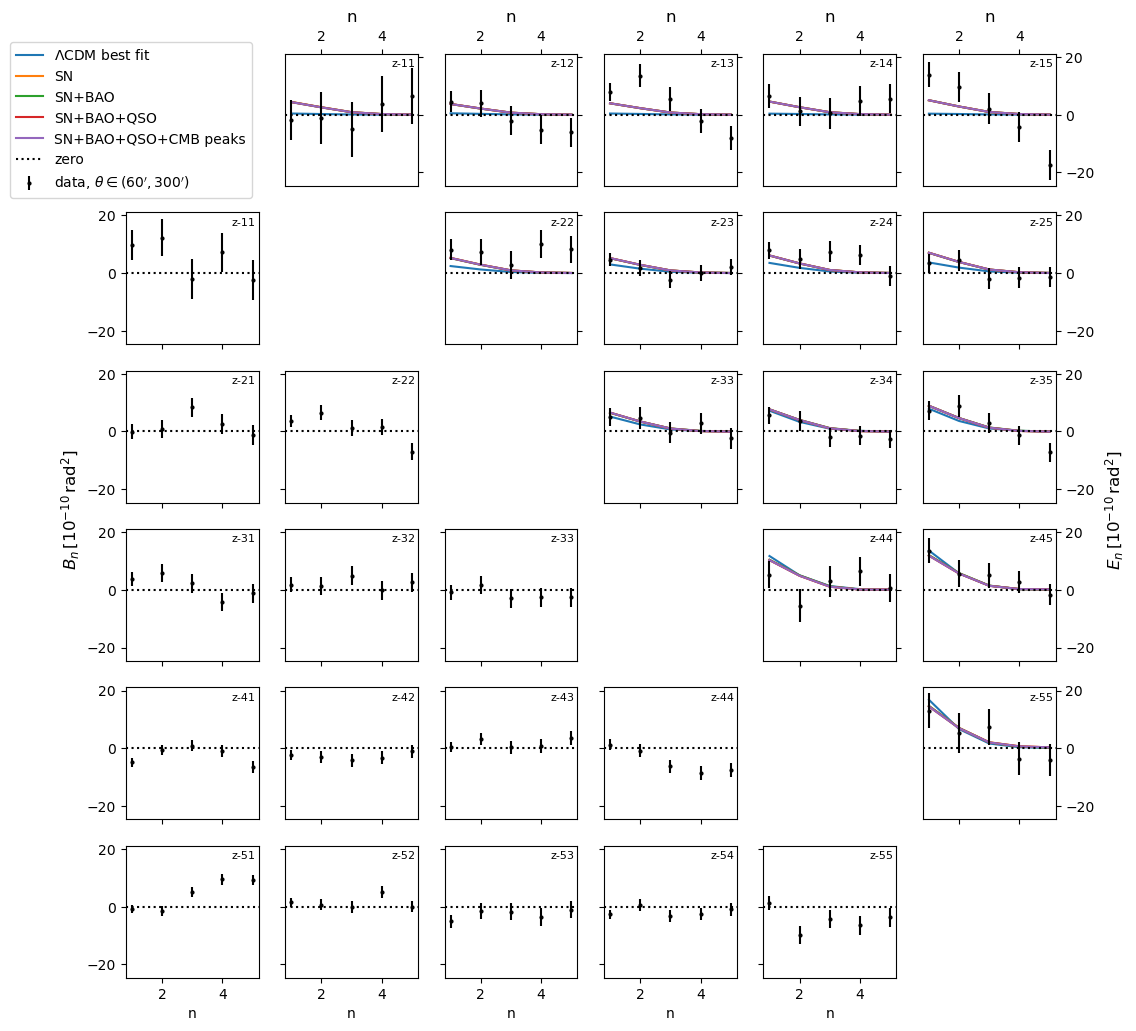

In [46]:
E_pattern = (
    "COSEBIs_60/En_COSEBIS_K1000_ALL_BLIND_C_V1.0.0A_ugriZYJHKs_photoz_"
    "SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid_theta_60.0_300_zbins_{i}_{j}.asc"
)
B_pattern = (
    "COSEBIs_60/Bn_COSEBIS_K1000_ALL_BLIND_C_V1.0.0A_ugriZYJHKs_photoz_"
    "SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid_theta_60.0_300_zbins_{i}_{j}.asc"
)
best_fit = np.loadtxt("data-theory_kids_lin.txt")[:,1] * 1e10
bf_sn = np.loadtxt("data-theory_SN.txt")[:,1] * 1e10
bf_sn_bao = np.loadtxt("data-theory_SN_BAO.txt")[:,1] * 1e10
bf_sn_bao_qso = np.loadtxt("data-theory_SN_BAO_QSO.txt")[:,1] * 1e10
bf_marie = np.loadtxt("data-theory_SN_BAO_QSO_Marie.txt")[:,1] * 1e10
n_bins = 5
modes_per_pair = 5
modes = np.arange(1, modes_per_pair + 1)

covE_file = "cov_en_60.ascii"   # 75x75 covariance for E-modes
covE = np.loadtxt(covE_file)
errE = np.sqrt(np.diag(covE))
covB_file = "cov_bn_60.ascii"   # 75x75 covariance for B-modes
covB = np.loadtxt(covB_file)
errB = np.sqrt(np.diag(covB))
fig,axes = plt.subplots(n_bins+1,n_bins+1,figsize=(12,12),sharex=True,sharey=True)
countB = 0
countE = 0
for i in range(0,n_bins+1) :
    for j in range(0,n_bins+1) :
        ax = axes[i,j]
        if i == j :
            ax.axis("off")
            continue
        if i>j :
            data = B_pattern.format(i=j+1,j=i)
            cosebis = np.loadtxt(data) * 1e10
            err = errB[5*countB : 5*countB + 5] * 1e10
            print(err)
            ax.errorbar(modes,cosebis,yerr=err, fmt="o", color="k", label=r"data, $\theta \in (60',300')$",markersize=2)
            ax.axhline(0, ls=":", color="k", label="zero")
            ax.text(0.80, 0.9, f"z-{i}{j+1}", transform=ax.transAxes, fontsize=8)
            if i==n_bins :
                ax.set_xlabel("n")
            if j == 0:
                ax.tick_params(labelleft=True)
            else:
                ax.tick_params(labelleft=False)
            countB+=1
        else :
            data = E_pattern.format(i=i+1,j=j)
            cosebis = np.loadtxt(data) * 1e10
            err = errE[5*countE : 5*countE + 5] * 1e10
            theory = best_fit[5*countE : 5*countE + 5]
            theory_sn = bf_sn[5*countE : 5*countE + 5]
            theory_sn_bao = bf_sn_bao[5*countE : 5*countE + 5]
            theory_sn_bao_qso = bf_sn_bao_qso[5*countE : 5*countE + 5]
            print(5*countE , 5*countE + 5)
            ax.plot(modes, theory, label=r"$\Lambda$CDM best fit")
            ax.plot(modes, theory_sn, label="SN")
            ax.plot(modes, theory_sn_bao, label="SN+BAO")
            ax.plot(modes, theory_sn_bao_qso,label="SN+BAO+QSO")
            ax.plot(modes, theory_sn_bao_qso,label="SN+BAO+QSO+CMB peaks")
            ax.errorbar(modes,cosebis,yerr=err, fmt="o", color="k", label=r"data, $\theta \in (60',300')$",markersize=2)
            ax.axhline(0, ls=":", color="k", label="zero")
            ax.yaxis.set_ticks_position("right")
            ax.text(0.80, 0.9, f"z-{i+1}{j}", transform=ax.transAxes, fontsize=8)
            if i==0 :
                ax.set_title("n")
                ax.xaxis.set_ticks_position("top")
            if j == n_bins:
                ax.tick_params(labelright=True)
            else:
                ax.tick_params(labelright=False)
            countE+=1
# Collect handles/labels from all axes
handles, labels = [], []
for row in axes:
    for ax in row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Deduplicate while keeping order
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))

# Put legend into the empty top-left subplot (0,0)
axes[0,0].legend(by_label.values(), by_label.keys(),
                 loc="right")

fig.text(0.07, 0.5, r"$B_n \,[10^{-10}\,\mathrm{rad}^2]$", 
         va="center", rotation="vertical", fontsize=12)

fig.text(0.94, 0.5, r"$E_n \,[10^{-10}\,\mathrm{rad}^2]$", 
         va="center", rotation="vertical", fontsize=12)

plt.savefig("modint_cosebis.pdf")


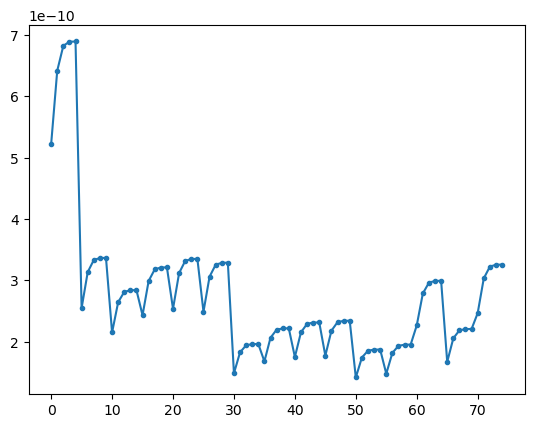

In [44]:
plt.plot(errB, marker='.')

In [41]:
import scipy.stats as stats

bmodes = []
for i in range(1, n_bins+1) :
    for j in range(i,n_bins+1) :
        data = B_pattern.format(i=i,j=j)
        cosebis = np.loadtxt(data)
        bmodes.append(cosebis)
bmodes = np.array(bmodes).flatten()

sigma = errB   # their errors
C = np.linalg.inv(covB)
chi22 = float(bmodes @ C @ bmodes)
dof = len(bmodes)  # number of data points
p_value = 1 - stats.chi2.cdf(chi22, dof)
print("p-value =", p_value)


p-value = 8.847485614138506e-07


In [3]:
for i in range(1,4) :
    print(i)

1
2
3


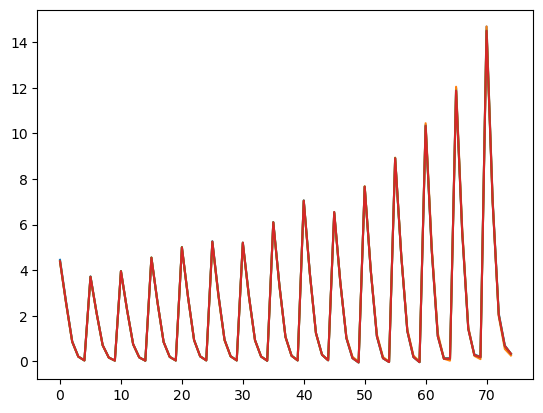

In [51]:
plt.plot(bf_sn)
plt.plot(bf_sn_bao)
plt.plot(bf_sn_bao_qso)
plt.plot(bf_marie)

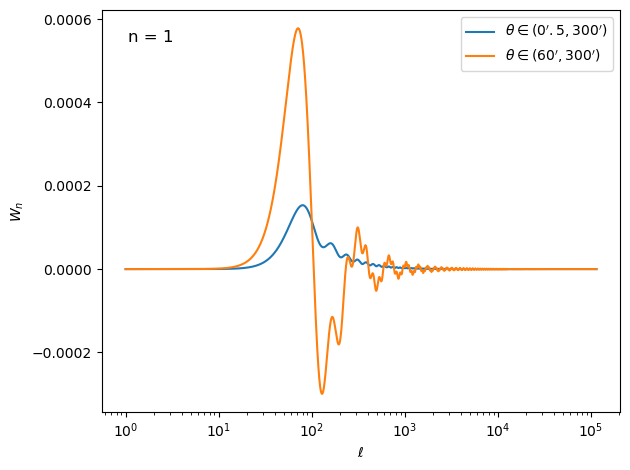

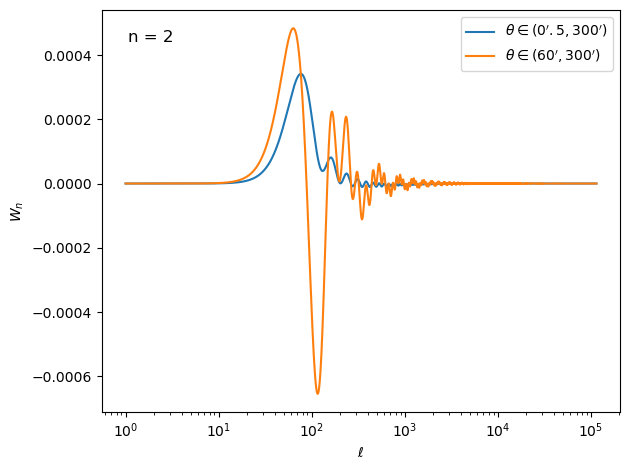

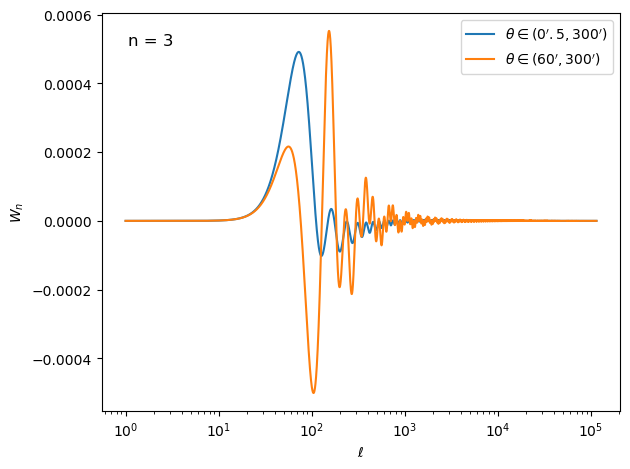

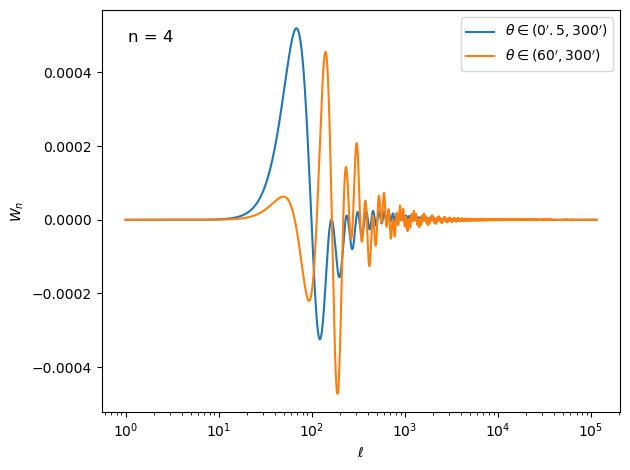

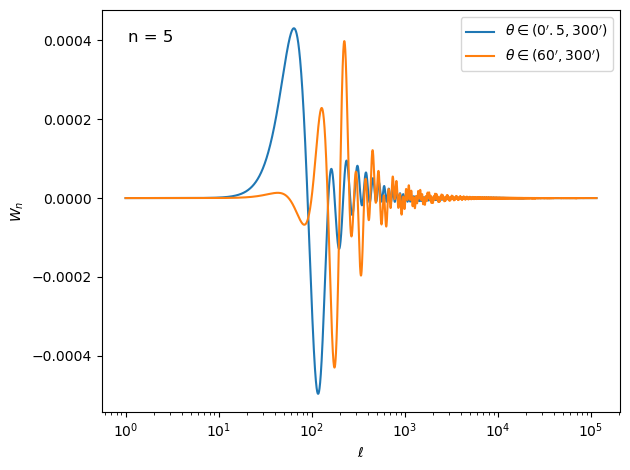

In [3]:
import numpy as np
import matplotlib.pyplot as plt

folder = "/home/steven/thesis/WnLog/"
wn05 = {}
wn60 = {}

for i in range(5):
    wn05[i+1] = np.loadtxt(folder + f"WnLog{i+1}-0.50-300.00.table")
    wn60[i+1] = np.loadtxt(folder + f"WnLog{i+1}-60.00-300.00.table")

    # plot with theta labels
    plt.semilogx(np.exp(wn05[i+1][:,0]), wn05[i+1][:,1],
                 label=r"$\theta \in (0'.5,300')$")
    plt.semilogx(np.exp(wn60[i+1][:,0]), wn60[i+1][:,1],
                 label=r"$\theta \in (60',300')$")

    # standard legend for theta ranges
    plt.legend()
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$W_n$")

    # add n=i text in the top-left corner (axes coords: 0=left/bottom, 1=right/top)
    plt.text(0.05, 0.95, f"n = {i+1}",
             transform=plt.gca().transAxes,
             ha="left", va="top",
             fontsize=12)
    plt.tight_layout()
    plt.savefig(f"W{i+1}.pdf")
    plt.show()


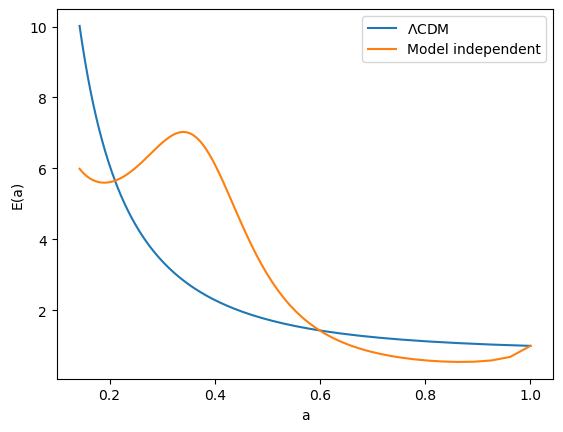

In [12]:
h0=0.6898
om=0.29044350092105475
n=-1
c = np.array([-1.4665944856188557,0.08477871541112725,-0.21832338086260628,0.55687597024763])
a = np.loadtxt("../a_bg.txt")

model = model_independent(c,a,h0,om,n)
model_expf = model.model_expf()
lcdm_expf = model.lcdm_expf()

plt.plot(a, lcdm_expf, label=r"$\Lambda$CDM")
plt.plot(a, model_expf, label="Model independent")
plt.xlabel("a")
plt.ylabel("E(a)")
plt.legend()